# Phân loại `ai_failure_rate` bằng Softmax (Multinomial Logistic Regression)

Notebook này kế thừa cách rời rạc hóa nhãn theo **Q-cut** (4 lớp) đã được kết luận là hợp lý nhất trong `naive_bayes_draft.ipynb`, sau đó triển khai và đánh giá thuật toán **Softmax** trên:

- Dữ liệu gốc (Original)
- Dữ liệu giảm chiều **PCA (28D)**
- Dữ liệu giảm chiều **TruncatedSVD (28D)**

Dataset gồm **150.000 bản ghi** = **10.000 công ty × ~15 lần khảo sát**. Do đó split train/test được thực hiện **theo `company_id`**: lấy N công ty đầu tiên (theo thứ tự ID) làm train, các công ty còn lại làm test — đảm bảo một công ty không xuất hiện ở cả hai tập (group-based, không leak). Ba kịch bản chia:

- **8000 công ty train / 2000 test**
- **7000 công ty train / 3000 test**
- **6000 công ty train / 4000 test**

Có baseline và tinh chỉnh siêu tham số bằng `GridSearchCV` với `GroupKFold` (CV vẫn group-aware).

In [1]:
import os
import json
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


def split_by_companies(X_data, y_data, groups, n_train_companies):
    """Chia train/test theo company_id: lấy n_train_companies ID đầu tiên (sau khi sort)
    cho train, các ID còn lại đi hết vào test. Đảm bảo không có công ty nào nằm trong cả 2 tập."""
    unique_companies = np.array(sorted(groups.unique()))
    train_companies = set(unique_companies[:n_train_companies].tolist())

    train_mask = groups.isin(train_companies).values
    test_mask  = ~train_mask

    X_train, X_test = X_data.loc[train_mask], X_data.loc[test_mask]
    y_train, y_test = y_data.loc[train_mask], y_data.loc[test_mask]
    g_train         = groups.loc[train_mask]
    return X_train, X_test, y_train, y_test, g_train

In [2]:
file_path = os.path.join("..", "processed_data", "encoded_ai_company_adoption.csv")
df = pd.read_csv(file_path)

meta_path = os.path.join("..", "processed_data", "meta_data.json")
with open(meta_path, "r", encoding="utf-8") as f:
    meta_data = json.load(f)

NUMERIC_ORDINAL_COLS = meta_data["numeric_ordinal_cols"]
ONEHOT_COLS         = meta_data["onehot_cols"]
CYCLIC_COLS         = meta_data["cyclic_cols"]
BINARY_COLS         = meta_data["binary_cols"]

target_col = 'ai_failure_rate'
if target_col in NUMERIC_ORDINAL_COLS:
    NUMERIC_ORDINAL_COLS.remove(target_col)

# Gắn company_id từ raw data (encoded CSV đã drop cột này; row order khớp 1-1)
raw_path = os.path.join("..", "data", "ai_company_adoption.csv")
raw_df = pd.read_csv(raw_path, usecols=['company_id'])
assert len(raw_df) == len(df), f"Row mismatch: raw={len(raw_df)}, encoded={len(df)}"
df['company_id'] = raw_df['company_id'].values

n_companies = df['company_id'].nunique()
counts_per_company = df['company_id'].value_counts()
print("Shape:", df.shape)
print(f"Số công ty duy nhất: {n_companies}")
print(f"Khảo sát/công ty — min={counts_per_company.min()}, "
      f"median={int(counts_per_company.median())}, "
      f"max={counts_per_company.max()}")
df.head()

Shape: (150000, 88)
Số công ty duy nhất: 10000
Khảo sát/công ty — min=10, median=15, max=16


,survey_year,company_size,num_employees,annual_revenue_usd_millions,company_age,ai_adoption_rate,ai_adoption_stage,years_using_ai,num_ai_tools_used,ai_projects_active,...,ai_use_case_Fraud Detection,ai_use_case_HR Automation,ai_use_case_Marketing Automation,ai_use_case_Medical Diagnostics,ai_use_case_Predictive Maintenance,ai_use_case_Software Development,ai_use_case_Supply Chain Optimization,cost_reduction_percent,customer_satisfaction,company_id
0,2023,0,57,48.31,29,30.57,1,3,1,3,...,0,0,0,0,0,0,0,9.45,5.20,COMP-00001
1,2023,0,57,48.31,29,27.25,1,4,3,0,...,0,0,0,0,0,1,0,0.00,6.98,COMP-00001
2,2023,0,57,48.31,29,31.54,1,2,3,3,...,0,1,0,0,0,0,0,9.74,4.12,COMP-00001
3,2023,0,57,48.31,29,11.02,1,2,1,2,...,0,0,0,0,0,1,0,0.00,5.72,COMP-00001
4,2024,0,57,48.31,30,33.39,1,7,3,5,...,0,0,0,0,0,0,0,9.02,6.31,COMP-00001


# Kế thừa rời rạc hóa nhãn bằng Q-cut

Trong `naive_bayes_draft.ipynb`, sau khi so sánh **K-Means, GMM, Q-cut**, Q-cut được chọn vì phân phối 4 lớp đều nhau (~37,5K mỗi lớp). Notebook này kế thừa trực tiếp cách chia đó.

In [3]:
n_bins = 4

df['qcut_class'], qcut_thresholds = pd.qcut(
    df[target_col], q=n_bins, labels=False, retbins=True
)

qcut_summary = (
    df.groupby('qcut_class')[target_col]
      .agg(['count', 'min', 'max'])
      .sort_values('min')
)
print(qcut_summary)
print("\nNgưỡng Q-cut:", np.round(qcut_thresholds, 2))

            count    min    max
qcut_class                     
0           37517   0.00  20.27
1           37543  20.28  25.88
2           37457  25.89  31.52
3           37483  31.53  40.00

Ngưỡng Q-cut: [ 0.   20.27 25.88 31.52 40.  ]


In [4]:
X = df.drop(columns=['ai_failure_rate', 'qcut_class', 'company_id'], errors='ignore')
y = df['qcut_class']
groups = df['company_id']  # dùng để split theo công ty (tránh leak)

labels_4_classes = ['Low', 'Medium', 'High', 'Critical']
print("X shape:", X.shape, "| y shape:", y.shape, "| n_groups:", groups.nunique())

X shape: (150000, 86) | y shape: (150000,) | n_groups: 10000


# Hàm tiện ích (chuẩn hóa & trực quan hóa)

Tái sử dụng cùng cách chuẩn hóa của `naive_bayes_draft.ipynb`:

- **Numeric/ordinal**: `StandardScaler` (z-score)
- **One-hot**: scale theo phong cách FAMD — `col / sqrt(col_mean_train)` để cân bằng trọng số giữa biến liên tục và biến nhị phân
- **Cyclic**: giữ nguyên (đã ở dạng sin/cos)

In [5]:
def preprocess_data(X_train, X_test):
    valid_num_cols = [c for c in NUMERIC_ORDINAL_COLS if c in X_train.columns]
    valid_cat_cols = [c for c in ONEHOT_COLS         if c in X_train.columns]
    valid_cyc_cols = [c for c in CYCLIC_COLS         if c in X_train.columns]

    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(X_train[valid_num_cols].astype(float))
    X_test_num  = scaler.transform(X_test[valid_num_cols].astype(float))

    X_train_cat = X_train[valid_cat_cols].astype(float).values
    X_test_cat  = X_test[valid_cat_cols].astype(float).values

    train_col_means = X_train_cat.mean(axis=0)
    train_col_means = np.where(train_col_means == 0, 1e-8, train_col_means)

    X_train_cat_scaled = X_train_cat / np.sqrt(train_col_means)
    X_test_cat_scaled  = X_test_cat  / np.sqrt(train_col_means)

    X_train_cyc = X_train[valid_cyc_cols].astype(float).values
    X_test_cyc  = X_test[valid_cyc_cols].astype(float).values

    X_train_combined = np.hstack([X_train_num, X_train_cat_scaled, X_train_cyc])
    X_test_combined  = np.hstack([X_test_num,  X_test_cat_scaled,  X_test_cyc])

    final_columns = valid_num_cols + valid_cat_cols + valid_cyc_cols
    X_train_combined = pd.DataFrame(X_train_combined, columns=final_columns, index=X_train.index)
    X_test_combined  = pd.DataFrame(X_test_combined,  columns=final_columns, index=X_test.index)
    return X_train_combined, X_test_combined

In [6]:
def plot_confusion_matrix(cm, classes, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(title, fontsize=14)
    plt.ylabel('Thực tế (Actual)', fontsize=12)
    plt.xlabel('Dự đoán (Predicted)', fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_classification_results(df_results, title_suffix='Softmax'):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'So sánh hiệu năng mô hình {title_suffix}', fontsize=16)

    sns.barplot(data=df_results, x='Split (Train:Test)', y='Test F1',
                hue='Data Type', ax=axes[0], palette='viridis')
    axes[0].set_title('Test F1-Score (Macro)', fontsize=14)
    axes[0].set_ylabel('F1-Score')
    axes[0].set_ylim(0, 1)

    sns.barplot(data=df_results, x='Split (Train:Test)', y='Test Acc',
                hue='Data Type', ax=axes[1], palette='magma')
    axes[1].set_title('Test Accuracy', fontsize=14)
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1)

    for ax in axes:
        for container in ax.containers:
            ax.bar_label(container, fmt='%.3f', padding=3, size=10)

    plt.tight_layout()
    plt.show()


def plot_gap_heatmap(df_results, title_suffix='Softmax'):
    gap_pivot = df_results.pivot(
        index='Data Type', columns='Split (Train:Test)', values='Gap Acc'
    )
    plt.figure(figsize=(8, 5))
    sns.heatmap(gap_pivot, annot=True, fmt='.3f', cmap='coolwarm',
                linewidths=0.5, center=0, vmin=-0.1, vmax=0.2)
    plt.title(f'Heatmap kiểm tra overfit ({title_suffix})', fontsize=14)
    plt.ylabel('Kiểu dữ liệu', fontsize=12)
    plt.xlabel('Tỉ lệ Train:Test (số công ty, đơn vị: nghìn)', fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_precision_recall_trends(df_results, title_suffix='Softmax'):
    plt.figure(figsize=(10, 6))
    markers = {'Original': 'o', 'PCA (28D)': 's', 'TruncatedSVD (28D)': '^'}

    for dt in df_results['Data Type'].unique():
        subset = df_results[df_results['Data Type'] == dt]
        m = markers.get(dt, 'o')
        plt.plot(subset['Split (Train:Test)'], subset['Test Precision'],
                 marker=m, linestyle='-', markersize=8,
                 label=f'Precision - {dt}')
        plt.plot(subset['Split (Train:Test)'], subset['Test Recall'],
                 marker=m, linestyle='--', markersize=8, alpha=0.7,
                 label=f'Recall - {dt}')

    plt.title(f'Biến động Precision và Recall theo tỉ lệ chia công ty ({title_suffix})', fontsize=14)
    plt.xlabel('Tỉ lệ Train:Test (số công ty, đơn vị: nghìn)', fontsize=12)
    plt.ylabel('Điểm số (0 → 1)', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_prediction_analysis(results_list, title_suffix='Softmax'):
    best_result = results_list[1]  # split 7000 train / 3000 test công ty
    y_actual = best_result['y_test_actual']
    y_pred   = best_result['y_test_pred']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        f'Đánh giá tương quan giữa thực tế và dự đoán ({title_suffix})',
        fontsize=16, fontweight='bold'
    )

    actual_counts = pd.Series(y_actual).value_counts().reindex(range(4)).fillna(0)
    pred_counts   = pd.Series(y_pred).value_counts().reindex(range(4)).fillna(0)

    x = np.arange(len(labels_4_classes))
    width = 0.35
    axes[0].bar(x - width / 2, actual_counts, width,
                label='Thực tế (Actual)', color='steelblue')
    axes[0].bar(x + width / 2, pred_counts, width,
                label='Dự đoán (Predicted)', color='darkorange')
    axes[0].set_title('Phân phối lớp: Thực tế vs Dự đoán', fontsize=14)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels_4_classes)
    axes[0].set_ylabel('Số lượng (Count)')
    axes[0].legend()
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    cm = confusion_matrix(y_actual, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Blues',
                xticklabels=labels_4_classes, yticklabels=labels_4_classes,
                ax=axes[1])
    axes[1].set_title('Tương quan tỉ lệ % (Dự đoán trên thực tế)', fontsize=14)
    axes[1].set_ylabel('Thực tế (Actual)', fontsize=12)
    axes[1].set_xlabel('Dự đoán (Predicted)', fontsize=12)

    plt.tight_layout()
    plt.show()

# Áp dụng mô hình Softmax (baseline)

Sử dụng `sklearn.linear_model.LogisticRegression` với `multi_class='multinomial'` (chính là Softmax Regression). Mô hình minimize cross-entropy loss đa lớp:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\sum_{k=1}^{K} y_{ik}\log\hat{p}_{ik}, \quad \hat{p}_{ik}=\frac{e^{w_k^\top x_i + b_k}}{\sum_{j=1}^{K} e^{w_j^\top x_i + b_j}}$$

Với 4 lớp Q-cut, $K = 4$.

### Kết quả mô hình

In [7]:
def run_softmax_baseline_experiment(X_data, y_data, groups, method='Original'):
    # Số công ty cho train: 8000 / 7000 / 6000 (trong tổng 10000)
    train_company_counts = [8000, 7000, 6000]
    total_companies = groups.nunique()
    results = []

    n_features_original = X_data.shape[1]
    target_components = max(1, n_features_original // 3)

    for n_train_co in train_company_counts:
        n_test_co = total_companies - n_train_co
        split_label = f"{n_train_co // 1000}:{n_test_co // 1000} co."

        # 1. Chia train/test theo công ty (tránh leak)
        X_train, X_test, y_train, y_test, _ = split_by_companies(
            X_data, y_data, groups,
            n_train_companies=n_train_co
        )

        # 2. Chuẩn hóa
        X_train_combined, X_test_combined = preprocess_data(X_train, X_test)

        # 3. Giảm chiều
        if method.upper() == 'ORIGINAL':
            X_train_final, X_test_final = X_train_combined, X_test_combined
            data_type_name = 'Original'

        elif method.upper() == 'PCA':
            reducer = PCA(n_components=target_components, random_state=42)
            X_train_final = reducer.fit_transform(X_train_combined)
            X_test_final  = reducer.transform(X_test_combined)
            data_type_name = f'PCA ({target_components}D)'

        elif method.upper() == 'SVD':
            reducer = TruncatedSVD(n_components=target_components, random_state=42)
            X_train_final = reducer.fit_transform(X_train_combined)
            X_test_final  = reducer.transform(X_test_combined)
            data_type_name = f'TruncatedSVD ({target_components}D)'
        else:
            raise ValueError("method chỉ hỗ trợ 'Original', 'PCA' hoặc 'SVD'")

        # 4. Model - Softmax (LogisticRegression đa lớp)
        y_train_arr = y_train.values if hasattr(y_train, 'values') else y_train

        model = LogisticRegression(
            multi_class='multinomial',
            solver='lbfgs',
            max_iter=1000,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train_final, y_train_arr)

        y_train_pred = model.predict(X_train_final)
        y_test_pred  = model.predict(X_test_final)

        # 5. Đánh giá
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc  = accuracy_score(y_test, y_test_pred)
        test_f1   = f1_score(y_test, y_test_pred, average='macro')
        test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
        test_recall    = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
        cm = confusion_matrix(y_test, y_test_pred)

        results.append({
            'Data Type':          data_type_name,
            'Split (Train:Test)': split_label,
            'N Train Companies':  n_train_co,
            'N Test Companies':   n_test_co,
            'N Train Rows':       len(X_train),
            'N Test Rows':        len(X_test),
            'Train Acc':          train_acc,
            'Test Acc':           test_acc,
            'Gap Acc':            train_acc - test_acc,
            'Test Precision':     test_precision,
            'Test Recall':        test_recall,
            'Test F1':            test_f1,
            'Confusion Matrix':   cm,

            'Model Object':       model,
            'X_train_raw':        X_train,
            'X_test_raw':         X_test,
            'y_test_actual':      y_test,
            'y_test_pred':        y_test_pred,
            'y_train_actual':     y_train,
            'y_train_pred':       y_train_pred,
        })

    return results

In [8]:
results_orig = run_softmax_baseline_experiment(X, y, groups, method='Original')
results_pca  = run_softmax_baseline_experiment(X, y, groups, method='PCA')
results_svd  = run_softmax_baseline_experiment(X, y, groups, method='SVD')

all_results = results_orig + results_pca + results_svd
df_results = pd.DataFrame(all_results)
display(df_results.drop(columns=[
    'Confusion Matrix', 'Model Object', 'X_train_raw', 'X_test_raw',
    'y_test_actual', 'y_test_pred', 'y_train_actual', 'y_train_pred'
]))

,Data Type,Split (Train:Test),N Train Companies,N Test Companies,N Train Rows,N Test Rows,Train Acc,Test Acc,Gap Acc,Test Precision,Test Recall,Test F1
0,Original,8:2 co.,8000,2000,120093,29907,0.543987,0.542281,0.001706,0.531258,0.541641,0.535231
1,Original,7:3 co.,7000,3000,105072,44928,0.544046,0.542179,0.001867,0.530656,0.541245,0.534684
2,Original,6:4 co.,6000,4000,90048,59952,0.543654,0.543301,0.000353,0.531697,0.542748,0.535804
3,PCA (28D),8:2 co.,8000,2000,120093,29907,0.496707,0.501521,-0.004815,0.485403,0.500847,0.490604
4,PCA (28D),7:3 co.,7000,3000,105072,44928,0.496802,0.499844,-0.003042,0.484022,0.498804,0.489013
5,PCA (28D),6:4 co.,6000,4000,90048,59952,0.496158,0.499800,-0.003642,0.484129,0.499175,0.489109
6,TruncatedSVD (28D),8:2 co.,8000,2000,120093,29907,0.497606,0.500217,-0.002611,0.483810,0.499536,0.489109
7,TruncatedSVD (28D),7:3 co.,7000,3000,105072,44928,0.497478,0.499622,-0.002144,0.483674,0.498581,0.488677
8,TruncatedSVD (28D),6:4 co.,6000,4000,90048,59952,0.496835,0.499583,-0.002748,0.483667,0.498959,0.488755


### Confusion Matrix (Split 7000:3000 công ty)

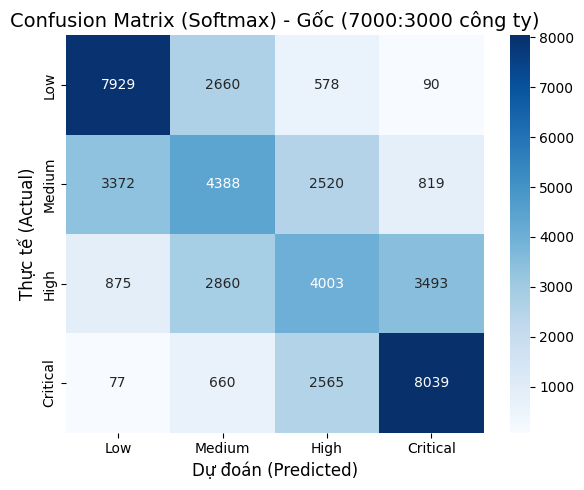

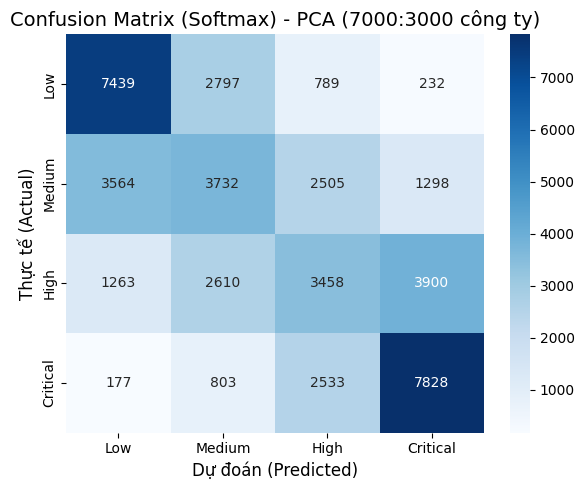

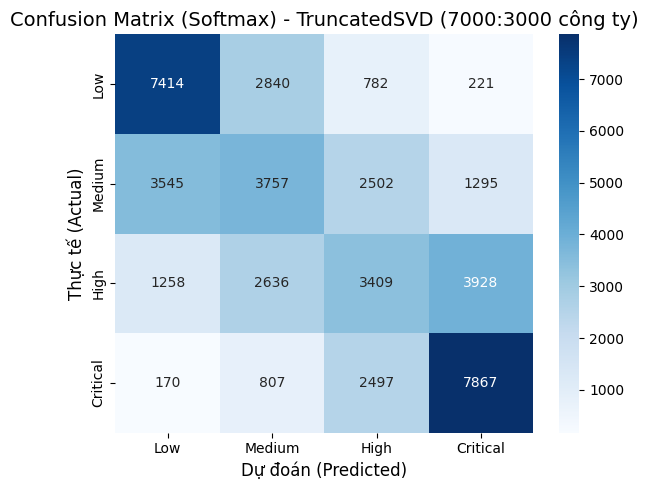

In [9]:
# Tương ứng split 7000 train / 3000 test công ty (index 1 trong mỗi list kết quả)
cm_orig = results_orig[1]['Confusion Matrix']
cm_pca  = results_pca[1]['Confusion Matrix']
cm_svd  = results_svd[1]['Confusion Matrix']

plot_confusion_matrix(cm_orig, labels_4_classes,
                      title='Confusion Matrix (Softmax) - Gốc (7000:3000 công ty)')
plot_confusion_matrix(cm_pca,  labels_4_classes,
                      title='Confusion Matrix (Softmax) - PCA (7000:3000 công ty)')
plot_confusion_matrix(cm_svd,  labels_4_classes,
                      title='Confusion Matrix (Softmax) - TruncatedSVD (7000:3000 công ty)')

### So sánh các tham số, kiểm tra overfit

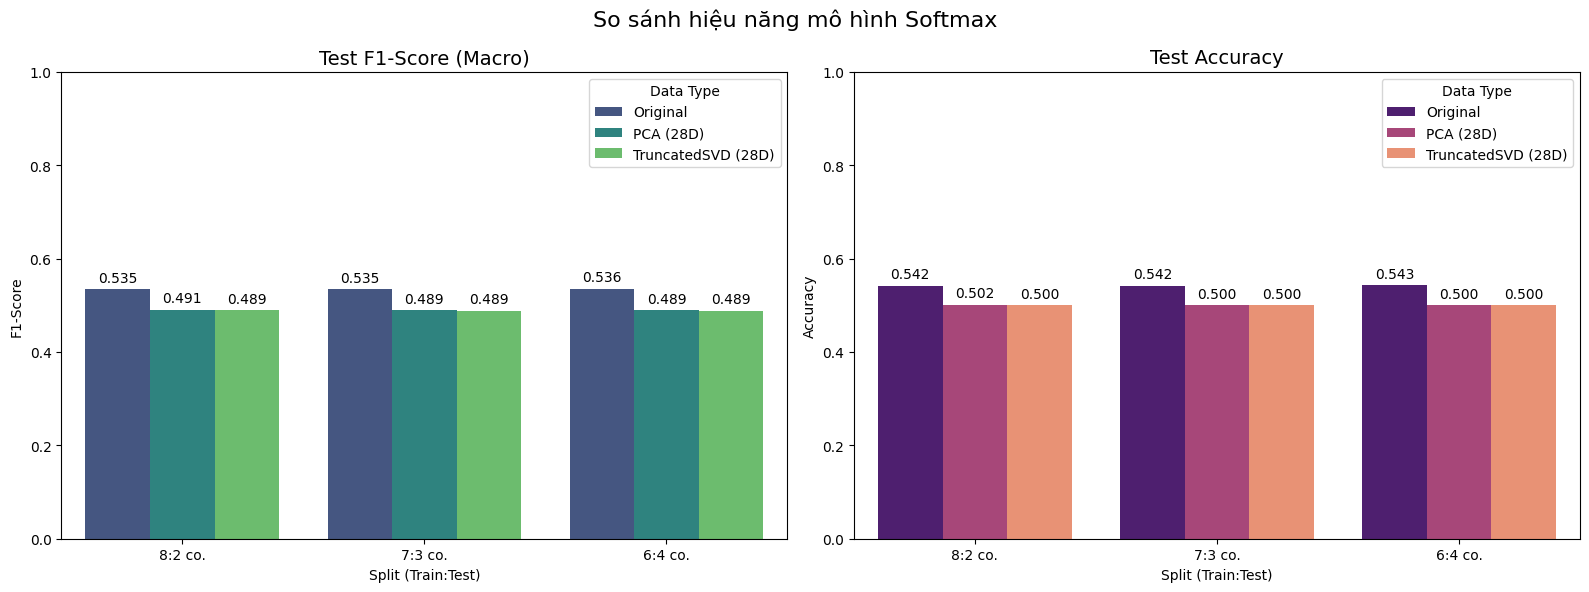

In [10]:
plot_classification_results(df_results, 'Softmax')

*Kiểm tra overfit*

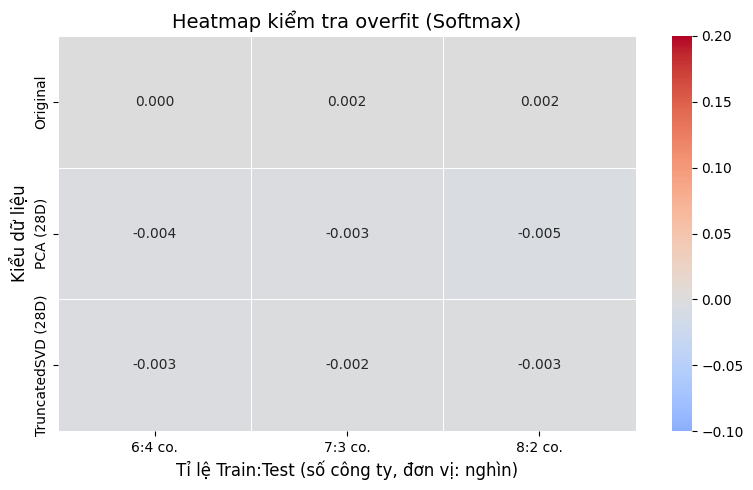

In [11]:
plot_gap_heatmap(df_results, 'Softmax')

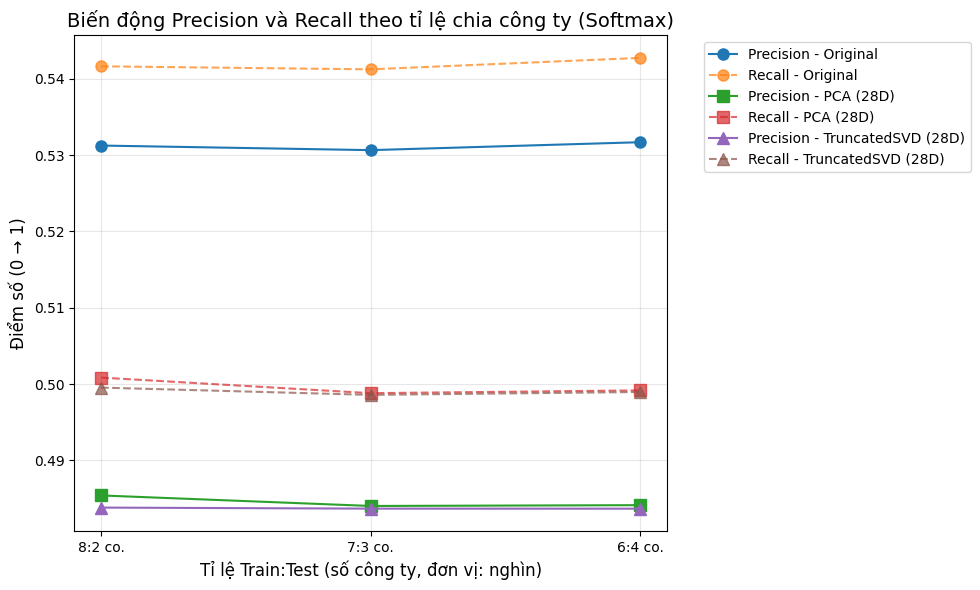

In [12]:
plot_precision_recall_trends(df_results, 'Softmax')

### Hiệu chỉnh

Tinh chỉnh `C` (cường độ regularization) và `penalty` (`l2`, `l1`, `elasticnet`) bằng `GridSearchCV` với CV = 5, scoring = `f1_macro`.

In [13]:
import time
from tqdm.auto import tqdm


def run_softmax_with_tuning(X_data, y_data, groups, method='Original'):
    train_company_counts = [8000, 7000, 6000]
    total_companies = groups.nunique()
    results = []

    n_features_original = X_data.shape[1]
    target_components = max(1, n_features_original // 3)

    # Grid bao phủ 3 penalty với solver tương thích
    param_grid = [
        {'C': [0.01, 0.1, 1.0, 10.0], 'penalty': ['l2'],         'solver': ['lbfgs']},
        {'C': [0.01, 0.1, 1.0, 10.0], 'penalty': ['l1'],         'solver': ['saga']},
        {'C': [0.01, 0.1, 1.0, 10.0], 'penalty': ['elasticnet'], 'solver': ['saga'], 'l1_ratio': [0.5]},
    ]

    pbar = tqdm(train_company_counts,
                desc=f'Tuning [{method}]',
                unit='split', leave=True)

    for n_train_co in pbar:
        n_test_co = total_companies - n_train_co
        split_label = f"{n_train_co // 1000}:{n_test_co // 1000} co."
        pbar.set_postfix_str(f'split={split_label} • fitting...')
        t0 = time.perf_counter()

        X_train, X_test, y_train, y_test, g_train = split_by_companies(
            X_data, y_data, groups,
            n_train_companies=n_train_co
        )
        X_train_combined, X_test_combined = preprocess_data(X_train, X_test)

        retained_variance = 1.0
        if method.upper() == 'ORIGINAL':
            X_train_final, X_test_final = X_train_combined, X_test_combined
            data_type_name = 'Original'
        elif method.upper() == 'PCA':
            reducer = PCA(n_components=target_components, random_state=42)
            X_train_final = reducer.fit_transform(X_train_combined)
            X_test_final  = reducer.transform(X_test_combined)
            retained_variance = reducer.explained_variance_ratio_.sum()
            data_type_name = f'PCA ({target_components}D)'
        elif method.upper() == 'SVD':
            reducer = TruncatedSVD(n_components=target_components, random_state=42)
            X_train_final = reducer.fit_transform(X_train_combined)
            X_test_final  = reducer.transform(X_test_combined)
            retained_variance = reducer.explained_variance_ratio_.sum()
            data_type_name = f'TruncatedSVD ({target_components}D)'

        y_train_arr = y_train.values if hasattr(y_train, 'values') else y_train

        base_estimator = LogisticRegression(
            multi_class='multinomial',
            max_iter=1000,
            random_state=42
        )
        # GroupKFold đảm bảo các fold CV không chia tách dữ liệu của cùng một công ty
        group_cv = GroupKFold(n_splits=5)
        grid_search = GridSearchCV(
            base_estimator,
            param_grid,
            cv=group_cv,
            scoring='f1_macro',
            n_jobs=-1,
            verbose=1,   # log mỗi candidate fit (mức nhẹ, không quá ồn)
        )
        grid_search.fit(X_train_final, y_train_arr, groups=g_train.values)

        best_model   = grid_search.best_estimator_
        best_params  = grid_search.best_params_

        y_train_pred = best_model.predict(X_train_final)
        y_test_pred  = best_model.predict(X_test_final)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc  = accuracy_score(y_test, y_test_pred)
        test_f1   = f1_score(y_test, y_test_pred, average='macro')
        test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
        test_recall    = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
        cm = confusion_matrix(y_test, y_test_pred)

        elapsed = time.perf_counter() - t0
        pbar.set_postfix_str(
            f'split={split_label} • {elapsed:.1f}s • '
            f'F1={test_f1:.3f} • {best_params.get("penalty")}'
        )

        results.append({
            'Data Type':          data_type_name,
            'Split (Train:Test)': split_label,
            'N Train Companies':  n_train_co,
            'N Test Companies':   n_test_co,
            'Retained Var':       retained_variance,
            'Best C':             best_params.get('C'),
            'Best Penalty':       best_params.get('penalty'),
            'Best Solver':        best_params.get('solver'),
            'Fit Time (s)':       round(elapsed, 1),
            'Train Acc':          train_acc,
            'Test Acc':           test_acc,
            'Gap Acc':            train_acc - test_acc,
            'Test Precision':     test_precision,
            'Test Recall':        test_recall,
            'Test F1':            test_f1,
            'Confusion Matrix':   cm,
        })

    return results


# Hiển thị tổng thời gian cho toàn bộ 3 method (mỗi method có 3 split)
total_t0 = time.perf_counter()
df_results_tuned = pd.DataFrame(
    run_softmax_with_tuning(X, y, groups, 'Original') +
    run_softmax_with_tuning(X, y, groups, 'PCA') +
    run_softmax_with_tuning(X, y, groups, 'SVD')
)
print(f"\nTổng thời gian tuning (3 method × 3 split): {time.perf_counter() - total_t0:.1f}s")
display(df_results_tuned.drop(columns=['Confusion Matrix']))

Tuning [Original]:   0%|          | 0/3 [00:00<?, ?split/s, split=8:2 co. • fitting...]

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Tuning [Original]:  33%|███▎      | 1/3 [15:00<30:00, 900.22s/split, split=7:3 co. • fitting...]                    

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Tuning [Original]:  67%|██████▋   | 2/3 [24:50<11:58, 718.05s/split, split=6:4 co. • fitting...]                    

...

Tuning [SVD]:  67%|██████▋   | 2/3 [00:45<00:22, 22.47s/split, split=6:4 co. • fitting...]           

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Tuning [SVD]: 100%|██████████| 3/3 [01:04<00:00, 21.52s/split, split=6:4 co. • 19.2s • F1=0.489 • l1]


Tổng thời gian tuning (3 method × 3 split): 2077.7s


,Data Type,Split (Train:Test),N Train Companies,N Test Companies,Retained Var,Best C,Best Penalty,Best Solver,Fit Time (s),Train Acc,Test Acc,Gap Acc,Test Precision,Test Recall,Test F1
0,Original,8:2 co.,8000,2000,1.000000,0.10,elasticnet,saga,900.2,0.543903,0.542850,0.001054,0.531748,0.542207,0.535740
1,Original,7:3 co.,7000,3000,1.000000,0.01,elasticnet,saga,590.5,0.544027,0.542112,0.001915,0.530157,0.541168,0.534308
2,Original,6:4 co.,6000,4000,1.000000,0.10,elasticnet,saga,459.6,0.543732,0.543351,0.000381,0.531734,0.542800,0.535838
3,PCA (28D),8:2 co.,8000,2000,0.584212,1.00,l1,saga,24.4,0.496723,0.501588,-0.004865,0.485499,0.500913,0.490695
4,PCA (28D),7:3 co.,7000,3000,0.584364,1.00,elasticnet,saga,18.7,0.496802,0.499933,-0.003131,0.484108,0.498893,0.489099
5,PCA (28D),6:4 co.,6000,4000,0.584631,0.10,elasticnet,saga,19.6,0.496058,0.499800,-0.003742,0.484091,0.499175,0.489079
6,TruncatedSVD (28D),8:2 co.,8000,2000,0.571988,0.10,l1,saga,23.9,0.497848,0.500351,-0.002504,0.483800,0.499667,0.489131
7,TruncatedSVD (28D),7:3 co.,7000,3000,0.572089,1.00,l2,lbfgs,21.5,0.497478,0.499622,-0.002144,0.483674,0.498581,0.488677
8,TruncatedSVD (28D),6:4 co.,6000,4000,0.572277,0.10,l1,saga,19.2,0.496724,0.499683,-0.002959,0.483741,0.499058,0.488808


### Trực quan hóa tương quan giữa thực tế và dự đoán

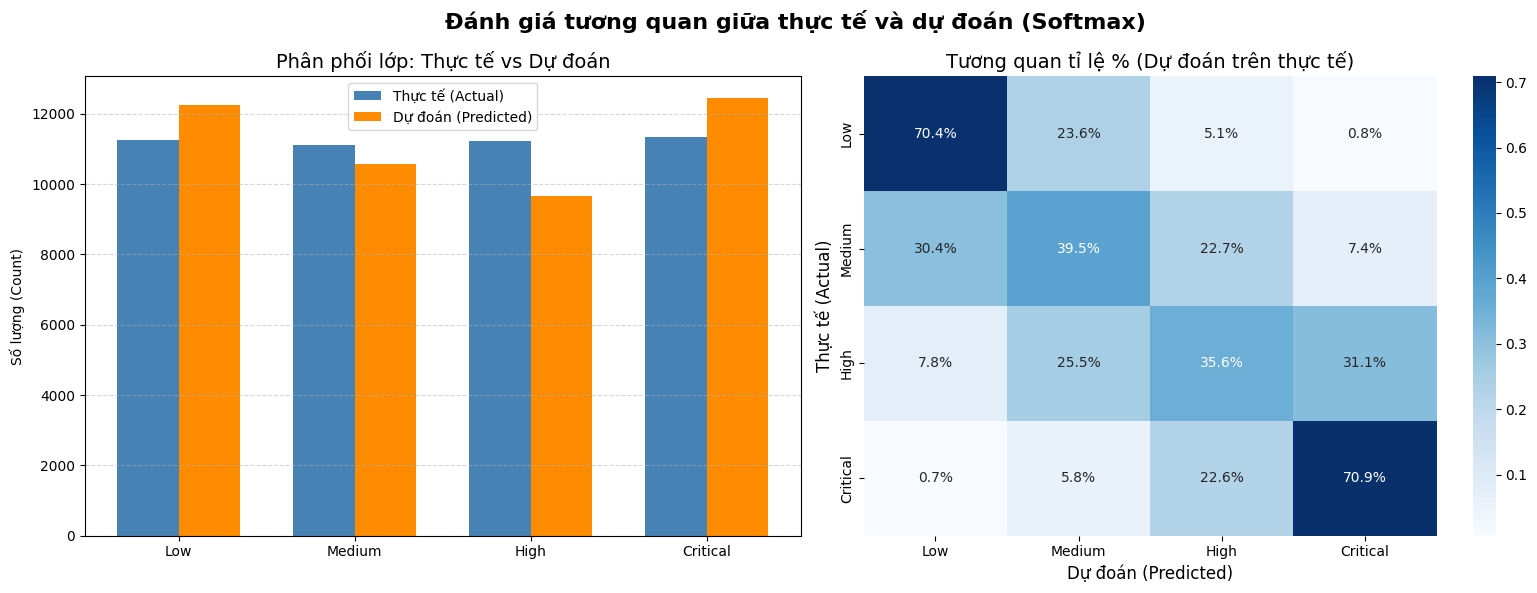

In [14]:
plot_prediction_analysis(results_orig, 'Softmax')